In [190]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [191]:
import pandas as pd
import numpy as np
from dowhy import CausalModel
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
from dowhy import CausalModel, gcm
import graphviz

In [192]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print(len(df))
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)]
print(len(df))
df.head()

6140
5612


,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670


In [193]:
counts = df['code_location'].value_counts()
print(counts)
print(len)

code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64
<built-in function len>


In [194]:
df["verdict"] = df["verdict"].astype(int)
# df["apk_size_mb"] = df["apk_size"] / 1000000
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["lib_category"] = df["code_location"].apply(lambda x: x if x != "developer_written" else "source")

df["code_location"].value_counts()
df.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size,is_third_party,lib_category
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,others
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,1,others
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,Android
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,1,Android
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670,1,Android


In [195]:
df["is_third_party"].value_counts()

is_third_party
1    5101
0     511
Name: count, dtype: int64

In [196]:

causal_graph = """
digraph {
    is_third_party -> verdict;
    apk_size -> is_third_party;
    apk_size -> verdict;
    apk_category -> is_third_party;
    apk_category -> verdict;
}
"""

causal_graph_2 = """
digraph {
    is_third_party -> verdict;
    apk_size -> is_third_party;
    apk_size -> verdict;
    apk_category -> is_third_party;
    apk_category -> verdict;
    apk_category -> apk_size;
}
"""

causal_graph_only_size = """
digraph {
    apk_size -> is_third_party;
    apk_size -> verdict;
    is_third_party -> verdict;
}
"""

causal_graph_only_apk_category = """
digraph {
    is_third_party -> verdict;
    apk_category -> is_third_party;
    apk_category -> verdict;
}
"""


causal_graph_after_correlation_test = """
digraph {
    is_third_party -> verdict;
    apk_size -> is_third_party;
    apk_category -> is_third_party;
    apk_category -> verdict;
    apk_category -> apk_size;
}
"""

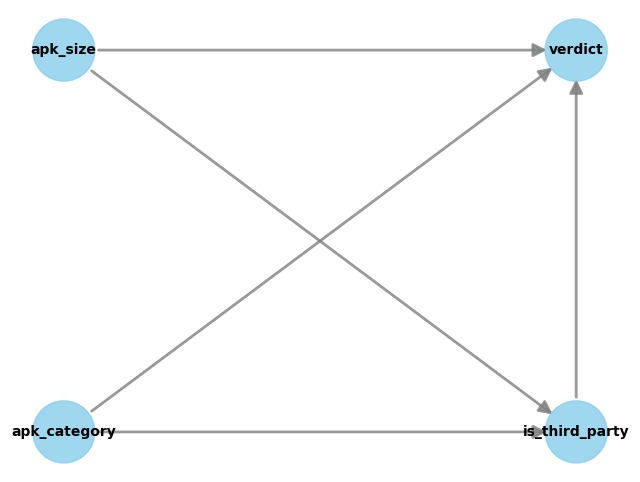

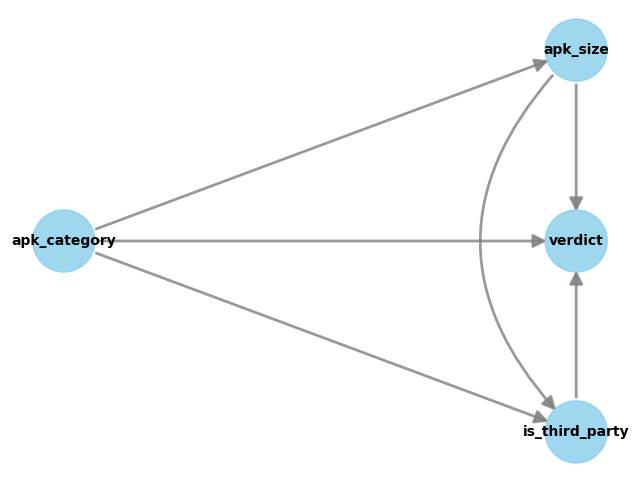

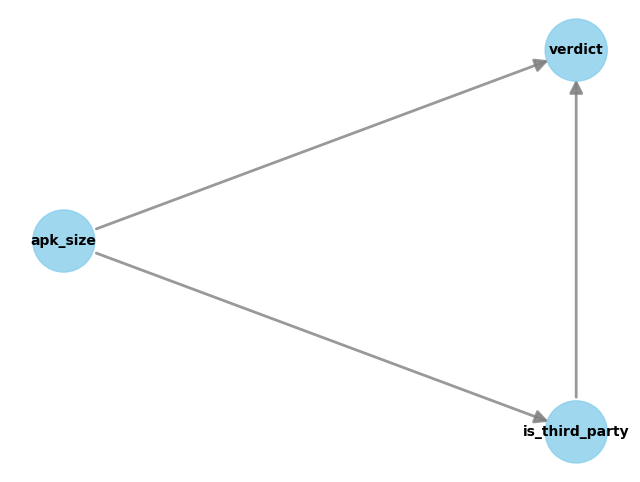

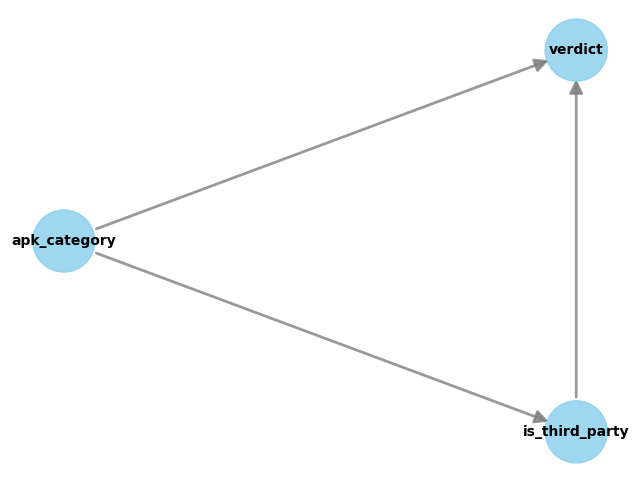

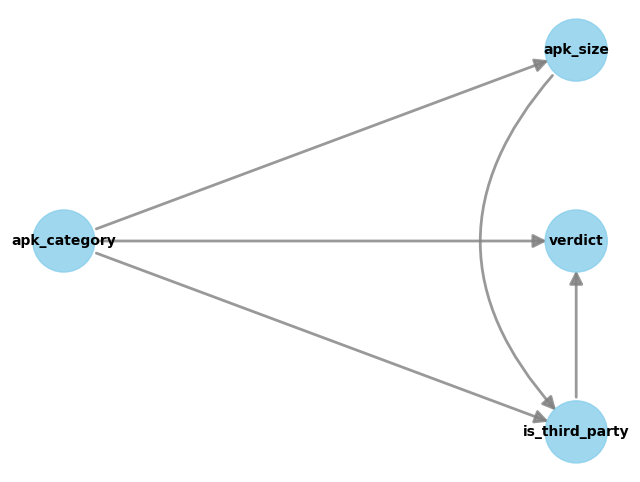

In [197]:
model = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph.replace("\n", " "),
    common_causes=["apk_size", "apk_category"]
)

model_2 = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_2.replace("\n", " "),
    common_causes=["apk_size", "apk_category"]
)

model_only_size = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_only_size.replace("\n", " "),
    common_causes=["apk_size"]
)
    
model_only_apk_category = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_only_apk_category.replace("\n", " "),
    common_causes=["apk_category"]
)

model_after_correlation_test = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph_after_correlation_test.replace("\n", " "),
    common_causes=["apk_category"]
)


model.view_model()
model_2.view_model()
model_only_size.view_model()
model_only_apk_category.view_model()
model_after_correlation_test.view_model()

In [198]:
df["apk_category"].value_counts()

apk_category
100k-500k    704
1M-5M        641
<100         626
100-500      604
500k-1M      602
>5M          518
10k-50k      449
5k-10k       415
50k-100k     413
1k-5k        323
500-1k       317
Name: count, dtype: int64

In [199]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_2 = model_2.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_only_size = model_only_size.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_only_apk_category = model_only_apk_category.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_after_correlation_test = model_after_correlation_test.identify_effect(proceed_when_unidentifiable=True)


print(identified_estimand, "\n", "------"*10)
print(identified_estimand_2, "\n", "------"*10)
print(identified_estimand_only_size, "\n", "------"*10)
print(identified_estimand_only_apk_category, "\n", "------"*10)
print(identified_estimand_after_correlation_test)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                          
─────────────────(E[verdict|apk_category,apk_size])
d[is_third_party]                                  
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_category,apk_size,U) = P(verdict|is_third_party,apk_category,apk_size)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                          
─────────────────(E[verdict|apk_category,apk_size])
d[is_third_party]                                  
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_category,apk_size,U) = P(verdict|is_third_party,apk_category,apk_size)
 
 ------

In [200]:
estimate = model.estimate_effect(identified_estimand, method_name="backdoor.propensity_score_matching", target_units = "ate", confidence_intervals=True)
estimate_2 = model_2.estimate_effect(identified_estimand_2, method_name="backdoor.propensity_score_matching", target_units = "ate", confidence_intervals=True)
estimate_only_size = model_only_size.estimate_effect(identified_estimand_only_size, method_name="backdoor.propensity_score_matching", target_units = "ate")
estimate_only_apk_category = model_only_apk_category.estimate_effect(identified_estimand_only_apk_category, method_name="backdoor.propensity_score_matching", target_units = "ate")
estimate_after_correlation_test = model_after_correlation_test.estimate_effect(identified_estimand_after_correlation_test, method_name="backdoor.propensity_score_matching", target_units = "ate")


print(estimate, "\n", "-------"*10)
print(estimate_2, "\n", "-------"*10)
print(estimate_only_size, "\n", "-------"*10)
print(estimate_only_apk_category, "\n", "-------"*10)
print(estimate_after_correlation_test)


*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                          
─────────────────(E[verdict|apk_category,apk_size])
d[is_third_party]                                  
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_category,apk_size,U) = P(verdict|is_third_party,apk_category,apk_size)

## Realized estimand
b: verdict~is_third_party+apk_category+apk_size
Target units: ate

## Estimate
Mean value: -0.27334283677833215
95.0% confidence interval: (np.float64(-0.38987883107626514), np.float64(-0.2017106200997862))
 
 ----------------------------------------------------------------------
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                    

In [201]:
refutation_methods = [
    # "add_unobserved_common_cause",
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]


print("----"*15, "Both size and apk category as confounders", "----"*15)
for method in refutation_methods:
    ref = model.refute_estimate(identified_estimand, estimate, method_name=method)
    print(f"\nRefuter: {method}\n",ref)

print("----"*15, "Both size and apk category as confounders 2", "----"*15)
for method in refutation_methods:
    ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method)
    print(f"\nRefuter: {method}\n",ref)


print("----"*15, "Only size as a confounder", "----"*15)
for method in refutation_methods:
    ref = model_only_size.refute_estimate(identified_estimand_only_size, estimate_only_size, method_name=method)
    print(f"\nRefuter: {method}\n",ref)

print("----"*15, "Only apk category as a confounder", "----"*15)
for method in refutation_methods:
    ref = model_only_apk_category.refute_estimate(identified_estimand_only_apk_category, estimate_only_apk_category, method_name=method)
    print(f"\nRefuter: {method}\n",ref)

print("----"*15, "Refutation after correlation test", "----"*15)
for method in refutation_methods:
    ref = model_test.refute_estimate(identified_estimand_after_correlation_test, estimate_after_correlation_test, method_name=method)
    print(f"\nRefuter: {method}\n",ref)


------------------------------------------------------------ Both size and apk category as confounders ------------------------------------------------------------

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.27334283677833215
New effect:-0.27334283677833227
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.27334283677833215
New effect:-0.0008838203848895222
p value:0.96


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.27334283677833215
New effect:-0.2582672605790646
p value:0.6799999999999999

------------------------------------------------------------ Both size and apk category as confounders 2 ------------------------------------------------------------

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.27334283677833215
New effect:-0.27334283677833227
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Tre

In [202]:
# p_value = gcm.independence_test(
#     df["apk_size"].values,
#     df["verdict"].values,
#     conditioned_on=df["is_third_party"].values, 
#     method='kernel'
# )
# p_value

### Rejected the null hypothesis on: 
# apk_category -> apk_size -> is_third_party
# lib_category -> is_third_party-> verdict
# 

# df["lib_category"] df["code_location"] df["is_third_party"]  .astype("category").cat.codes.values

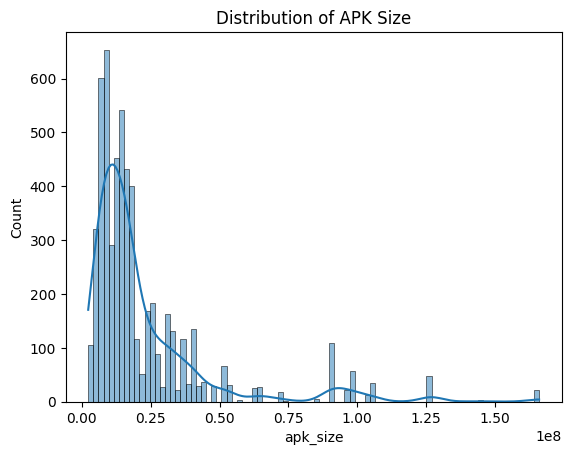

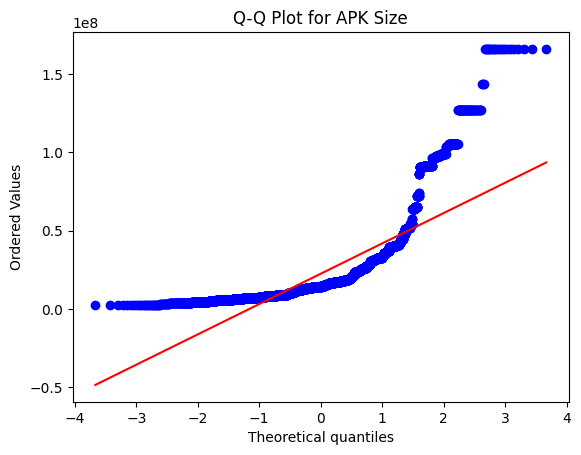

In [203]:
import seaborn as sns
import scipy.stats as stats

sns.histplot(df["apk_size"], kde=True)
plt.title("Distribution of APK Size")
plt.xlabel("apk_size")
plt.show()

stats.probplot(df["apk_size"], dist="norm", plot=plt)
plt.title("Q-Q Plot for APK Size")
plt.show()


In [204]:
# That means, data is not normally distributed, it is right skewed. So, we can not use the ANOVA, we can use the Kruskal-Wallis H-test (more than 3 independent groups available in our apk_category)) instead for non-parametric data.

In [205]:
# import seaborn as sns
# sns.boxplot(x="apk_category", y="apk_size", data=df)
# plt.xticks(rotation=45)
# plt.title("APK Size by Category")
# plt.show()



In [206]:
from scipy.stats import kruskal

groups = [g["apk_size"].values for _, g in df.groupby("apk_category", observed=True)]
H_stat, p_value = kruskal(*groups)

# n = len(df)                     
# k = df["apk_category"].nunique() 
# eta_squared = (H_stat - k + 1) / (n - k)

print("-----"*10, "Correlation Test for apk_category -> apk_size", "-----"*10)
print(f"Kruskal–Wallis H = {H_stat:.3f}")
print(f"p-value = {p_value:.5f}")
# print(f"Effect size (η²) = {eta_squared:.4f}")
print(f"Number of categories = {k}, Total samples = {n}")

if p_value < 0.05:
    print("As the p value is less than 0.05, we can say that there is a statistically significant association between the apk_category and apk_size. It provides evidence to support the hypothesis that the apk_category influences apk_size. There is correlation in the apk_category -> apk_size")
else:
    print("\n As the p value is greater than or equal than 0.05, No statistically significant difference detected between APK categories. There is no correlation in the apk_category -> apk_size direction.")


# if eta_squared < 0.01:
#     print("Effect size: negligible")
# elif eta_squared < 0.06:
#     print("Effect size: small")
# elif eta_squared < 0.14:
#     print("Effect size: medium")
# else:
#     print("Effect size: large")



-------------------------------------------------- Correlation Test for apk_category -> apk_size --------------------------------------------------
Kruskal–Wallis H = 655.523
p-value = 0.00000
Number of categories = 11, Total samples = 5612
As the p value is less than 0.05, we can say that there is a statistically significant association between the apk_category and apk_size. It provides evidence to support the hypothesis that the apk_category influences apk_size. There is correlation in the apk_category -> apk_size


In [207]:
from scipy.stats import mannwhitneyu, kruskal

def mann_whitney_test(df, numeric_col, binary_col):
    groups = [df[df[binary_col] == val][numeric_col] for val in df[binary_col].unique()]
    stat, p = mannwhitneyu(groups[0], groups[1], alternative="two-sided")
    print(f"\n{numeric_col} -> {binary_col}")
    print(f"U = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("Significant difference — likely correlation between variables.")
    else:
        print("No significant difference — weak or no correlation.")
    return stat, p


def kruskal_test(df, cat_col, binary_col):
    groups = [group[binary_col].values for _, group in df.groupby(cat_col)]
    stat, p = kruskal(*groups)
    print(f"\n{cat_col} -> {binary_col}")
    print(f"H = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("Significant difference — likely correlation between variables.")
    else:
        print("No significant difference — weak or no correlation.")
    return stat, p


mann_whitney_test(df, "apk_size", "verdict")
mann_whitney_test(df, "apk_size", "is_third_party")
kruskal_test(df, "apk_category", "verdict")
kruskal_test(df, "apk_category", "is_third_party")



apk_size -> verdict
U = 3924870.000, p = 0.8988
No significant difference — weak or no correlation.

apk_size -> is_third_party
U = 1462973.000, p = 0.0000
Significant difference — likely correlation between variables.

apk_category -> verdict
H = 55.268, p = 0.0000
Significant difference — likely correlation between variables.

apk_category -> is_third_party
H = 102.328, p = 0.0000
Significant difference — likely correlation between variables.
